# AlexNet Visualization

The scene takes a single trained AlexNet, picks one output position in its first conv layer, and visually
wires together three things:

1. the small patch of the input image that produced that output,
2. the conv-1 filter (kernel) that did the producing, painted directly into that patch, and
3. the resulting activation values, across all 64 channels, drawn as a column of colored voxels.

Then it slides that wiring across every position in the 55&times;55 output grid, in raster order, while the
camera slowly moves &mdash; which is what turns a static diagram into the "kernel walking across the image"
animation.

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image

RESNETS_DIR = os.path.abspath('./images/')
sys.path.insert(0, RESNETS_DIR)
plt.rcParams['figure.facecolor'] = 'white'


## 1. Getting real activations: `alexnet_assets_gen.py`

We can re-create what happens during the `activations()` function from `alexnet_assets_gen.py`

The image is loaded and prepared to be input into AlexNet. The image is resized to 224x224, converted to a tensor, normalized, then a batch dimension is added.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.64].


Original Image - Width: 2000, Height: 1863
Resized image - Width: 224, Height: 224
Final AlexNet Input Shape: torch.Size([1, 3, 224, 224])


/tmp/ipykernel_12035/2588359833.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


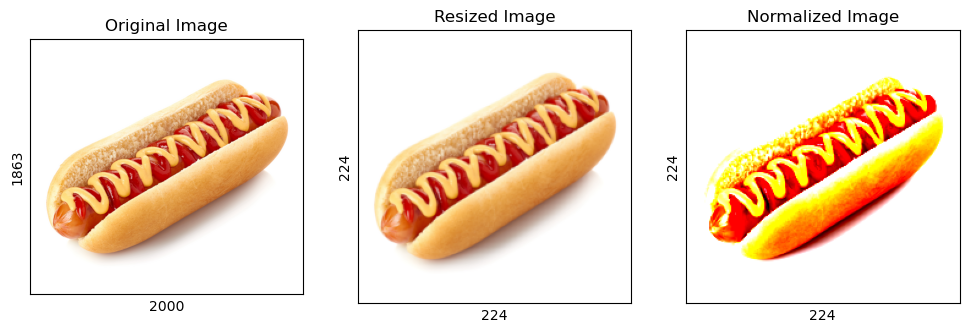

In [2]:
from torchvision import transforms

# Open the image
original_im = Image.open(os.path.join(RESNETS_DIR, 'hot_dog.png')).convert('RGB')
width, height = original_im.size
print(f"Original Image - Width: {width}, Height: {height}")

# Resize the image to 224x224 pixels
resized_im = transforms.Resize((224, 224))(original_im)
width, height = resized_im.size
print(f"Resized image - Width: {width}, Height: {height}")

# Convert the image to a tensor object and normalize the values
im = transforms.ToTensor()(resized_im)
norm_im = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])(im)

# Add a batch dimension for the input to AlexNet
img_input_tensor = norm_im.unsqueeze(0)

print(f"Final AlexNet Input Shape: {img_input_tensor.shape}")

fig, axes = plt.subplots(1, 3, figsize=(12,5))
axes[0].imshow(original_im)
axes[0].set_title("Original Image")
axes[0].set_xlabel(original_im.size[0])
axes[0].set_ylabel(original_im.size[1])

axes[1].imshow(resized_im)
axes[1].set_title("Resized Image")
axes[1].set_xlabel(resized_im.size[0])
axes[1].set_ylabel(resized_im.size[1])

axes[2].imshow(norm_im.permute(1,2,0))
axes[2].set_title("Normalized Image")
axes[2].set_xlabel(norm_im.shape[1])
axes[2].set_ylabel(norm_im.shape[2])

for ax in axes:
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

fig.show()

In [3]:
import torchvision.models as models
alexnet=models.alexnet(weights='IMAGENET1K_V1')
alexnet.eval()

# Slice into the features of AlexNet
selected_feature=2
print("Features selected:")
print(alexnet.features[:selected_feature])

# Pass the input image through the first <seleccted_feature> features
with torch.no_grad():
    activations = alexnet.features[:selected_feature](img_input_tensor).cpu().numpy()[0]
    
weights = alexnet.features[0].weight.detach().cpu().numpy()   # conv1 kernels, (64, 3, 11, 11)
    
print(f"Activation tensor:", activations.shape, activations.dtype)
print(f"Conv2d kernel weights:", weights.shape)


Features selected:
Sequential(
  (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
  (1): ReLU(inplace=True)
)
Activation tensor: (64, 55, 55) float32
Conv2d kernel weights: (64, 3, 11, 11)


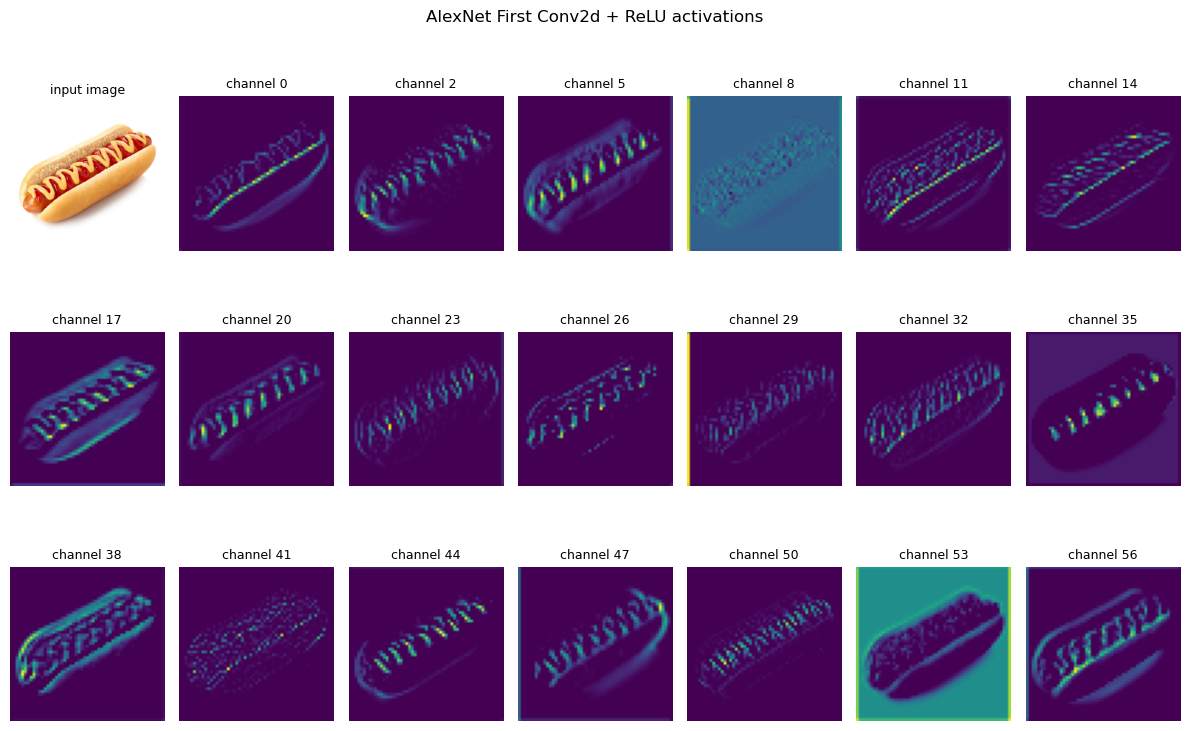

In [4]:
# Show what the hot dog looks like for the image
nrows=3
ncols=7

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 8))
axes = axes.flatten()
axes[0].imshow(original_im)
axes[0].set_title('input image', fontsize=9)
axes[0].axis('off')

channels = np.linspace(0, 56, num=(nrows*ncols)-1, dtype=np.int16)
for ax, ch in zip(axes[1:], channels):
    ax.imshow(activations[ch], cmap='viridis')
    ax.set_title(f'channel {ch}', fontsize=9)
    ax.axis('off')
fig.suptitle(f'AlexNet First Conv2d + ReLU activations')
plt.tight_layout()
plt.show()

### Kernel Activations

In [5]:
def plot_channel_activations(activations, channel):
    fig, ax = plt.subplots(figsize=(2, 3.5))
    ax.imshow(activations[channel], cmap='viridis')
    ax.set_title(f'channel {channel}', fontsize=9)
    ax.axis('off')
    plt.show()

def plot_kernel_weights(weights, channel):
    limit = np.abs(weights).max()
    
    fig, axes = plt.subplots(1, 3, figsize=(6, 2))

    input_channel_color = {0:"Red", 1:"Green", 2:"Blue"}
    # Show RGB kernels
    for input_ch in range(3):
        axes[input_ch].imshow(
            weights[channel, input_ch],
            cmap="coolwarm",
            vmin=-limit,
            vmax=limit,
        )
        axes[input_ch].set_title(f"{input_channel_color[input_ch]}")
        axes[input_ch].axis("off")

    plt.suptitle(f"Kernel weights for output channel {channel}")
    plt.tight_layout()
    plt.show()
    
def plot_kernel_rgb(weights, channel):

    kernel = weights[channel]

    # [3, H, W] -> [H, W, 3]
    kernel = np.moveaxis(kernel, 0, -1)

    # Normalize symmetrically around zero
    limit = np.abs(kernel).max()

    rgb_kernel = (
        kernel / (2 * limit) + 0.5
    )

    rgb_kernel = np.clip(rgb_kernel, 0, 1)
    
    plt.figure(figsize=(3, 3))
    plt.imshow(rgb_kernel)
    plt.title("Combined RGB kernel")
    plt.axis("off")
    plt.show()

Some of the channels pick up on things like edges, colors, textures, or boundaries.

- Channel 0: Diagonal edges
- Channel 8: Textures
- Channel 9: Vertical Stripes
- Channel 41: Diagonal Stripes

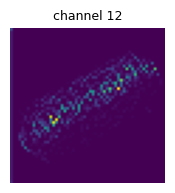

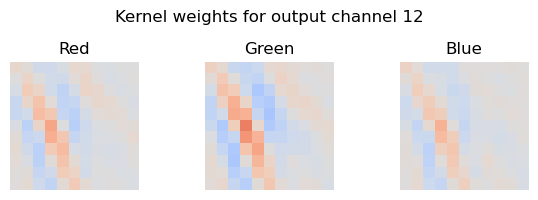

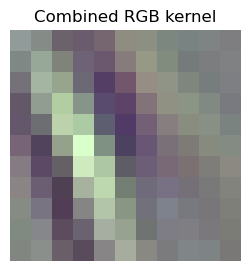

In [6]:
channel=12
plot_channel_activations(activations, channel)
plot_kernel_weights(weights, channel)
plot_kernel_rgb(weights, channel)

### Generate a video of the Conv2d Activations

In [8]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import imageio.v2 as imageio

generate_video = True
if generate_video:
    animation_dir = Path(
        "./animations"
    )
    animation_dir.mkdir(parents=True, exist_ok=True)

    video_path = animation_dir / "conv2d_activation.mp4"

    stride = 4
    kernel = 11
    padding = 4

    layout = [
        ["A", "A", "B", "C", "D"],
        ["A", "A", "E", "F", "G"],
        ["A", "A", "H", "I", "J"],
    ]

    avail_plots = ["B", "C", "D", "E", "F", "G", "H", "I", "J"]

    # activations assumed to have shape:
    # [channels, activation_height, activation_width]
    n_channels, activation_height, activation_width = activations.shape

    # Only plot as many channels as we have axes for
    n_channels_to_plot = min(len(avail_plots), n_channels)

    # Keep activation color scales fixed between frames.
    # This is important for the GIF, otherwise the colors will rescale
    # every frame.
    channel_vmin = [
        activations[ch].min()
        for ch in range(n_channels_to_plot)
    ]

    channel_vmax = [
        activations[ch].max()
        for ch in range(n_channels_to_plot)
    ]

    n_frames = activation_height * activation_width

    frame_idx = 0
    frame_skip = 9

    writer = imageio.get_writer(
        video_path,
        fps=24,
        codec="libx264",
    )

    px_width, px_height = 496, 368
    my_dpi = 100

    for flat_idx in range(0, activation_height * activation_width, frame_skip):
        i, j = np.unravel_index(
            flat_idx,
            (activation_height, activation_width),
        )

        # Receptive field corresponding to activation[i, j]
        y0 = i * stride - padding
        x0 = j * stride - padding

        fig, ax_dict = plt.subplot_mosaic(
            layout,
            figsize=(px_width / my_dpi, px_height / my_dpi), 
            dpi=my_dpi
        )

        # Original image
        ax = ax_dict["A"]
        
        padded_im = np.pad(
            np.asarray(resized_im),
            (
                (padding, padding),
                (padding, padding),
                (0, 0),
            ),
            mode="constant",
            constant_values=128,
        )
        ax_dict["A"].imshow(padded_im)
        
        rect = patches.Rectangle(
            xy=(x0, y0),
            width=kernel,
            height=kernel,
            edgecolor="#19C338",
            facecolor="none",
            linewidth=2,
        )
        ax.add_patch(rect)

        ax.tick_params(
            left=False,
            bottom=False,
            labelleft=False,
            labelbottom=False,
        )

        # Which activation values have been seen so far?
        current_flat_idx = flat_idx
        
        # Plot each channel's activations up to the current position
        for ch, ax_letter in enumerate(
            avail_plots[:n_channels_to_plot]
        ):
            ax = ax_dict[ax_letter]

            channel_activation = activations[ch]

            # Start with a zero matrix
            visible_activations = np.full_like(
                channel_activation,
                np.nan,
            )

            # Flatten both arrays so revealing everything through the current position is simple.
            source_flat = channel_activation.ravel()
            visible_flat = visible_activations.ravel()

            visible_flat[: current_flat_idx + 1] = (
                source_flat[: current_flat_idx + 1]
            )

            # Keep the activation min and max values the same across all figures
            cmap = plt.cm.viridis.copy()
            cmap.set_bad(alpha=0)

            ax.imshow(
                visible_activations,
                cmap=cmap,
                vmin=channel_vmin[ch],
                vmax=channel_vmax[ch],
            )

            ax.set_title(f"channel {ch}")
            ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

            # Highlight the activation whose receptive field
            # is currently shown.
            activation_rect = patches.Rectangle(
                xy=(j - 0.5, i - 0.5),
                width=1,
                height=1,
                edgecolor="#19C338",
                facecolor="none",
                linewidth=1.5,
            )

            ax.add_patch(activation_rect)

        # Hide unused subplot positions, if fewer than 9 channels
        for ax_letter in avail_plots[n_channels_to_plot:]:
            ax_dict[ax_letter].axis("off")

        # Figure formatting
        fig.set_facecolor("#E6F2F7")

        fig.subplots_adjust(
            left=0.02,
            right=0.98,
            bottom=0.02,
            top=0.90,
            wspace=0.15,
            hspace=0.30,
        )

        fig.canvas.draw()

        frame = np.asarray(fig.canvas.buffer_rgba())[..., :3]

        writer.append_data(frame)

        plt.close(fig)

    writer.close()

    print(f"Saved to {video_path}")

Saved to animations/conv2d_activation.mp4


## 2. The 55×55 grid: receptive fields and stride

AlexNet's conv-1 uses an 11&times;11 kernel with stride 4 over a 224&times;224 input, which is what produces a
55&times;55 output grid (`floor((224-11)/4)+1 = 54`... torchvision's exact padding gets it to 55). Each output
cell `(i, j)` corresponds to an 11&times;11 patch of the input starting near pixel `(4*i, 4*j)`.

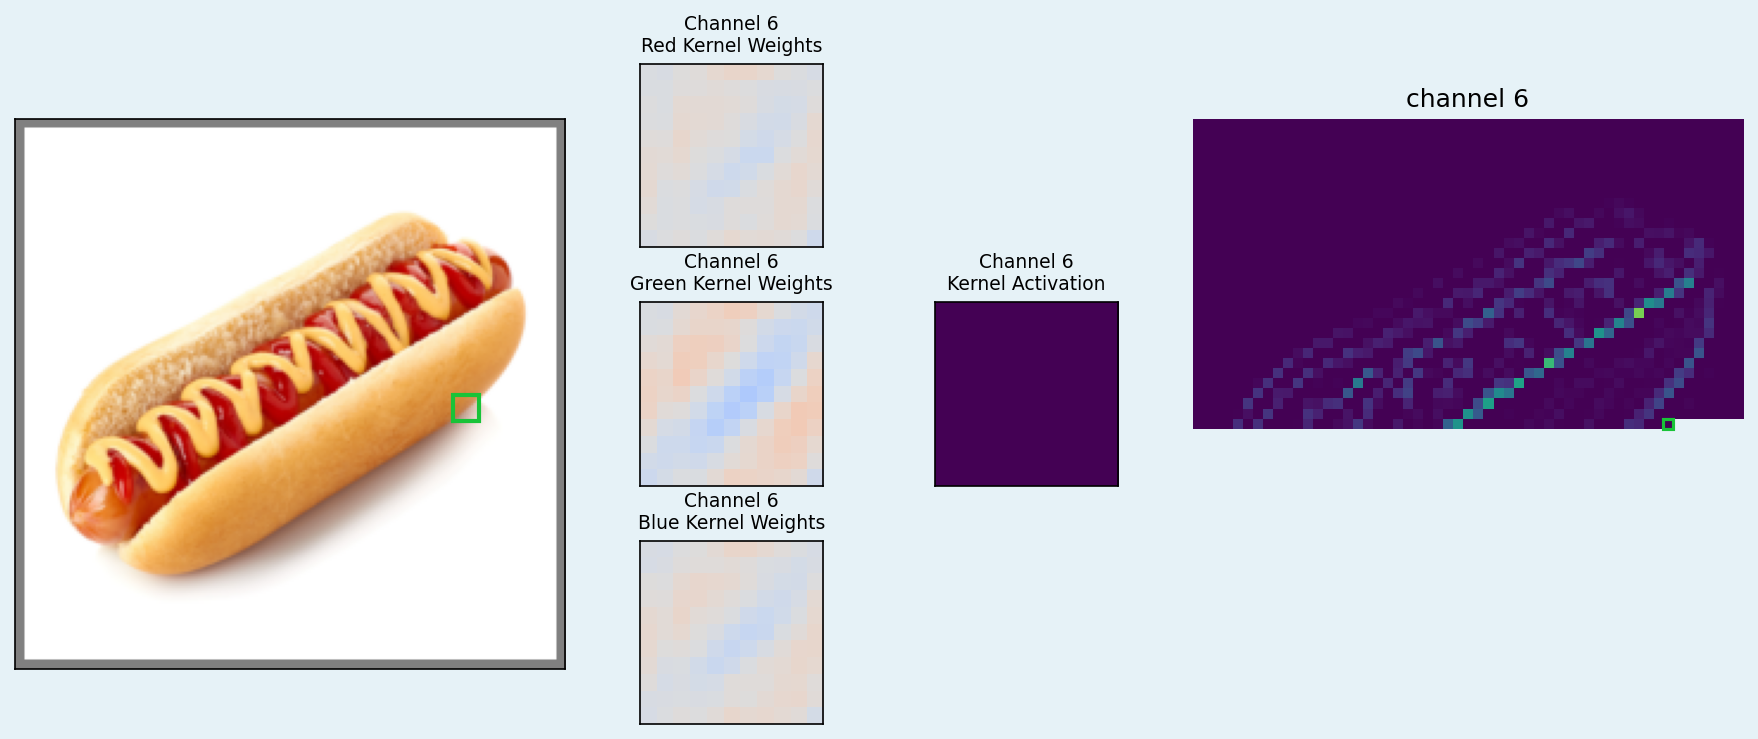

In [ ]:
from matplotlib.colors import Normalize

def plot_channel_activation_by_position(i, j, channel_n=0, stride=4, kernel=11, padding=4):
    
    layout = [
        ["A", "A", "B1", ".", "D", "D"],
        ["A", "A", "B2", "C", "D", "D"],
        ["A", "A", "B3", ".", "D", "D"],
    ]
        
    # Receptive field corresponding to activation[i, j]
    y0 = i * stride - padding
    x0 = j * stride - padding

    n_channels, activation_height, activation_width = activations.shape

    fig, ax_dict = plt.subplot_mosaic(
        layout,
        figsize=(12, 5), 
        dpi=150
    )

    # Original image
    ax = ax_dict["A"]

    padded_im = np.pad(
        np.asarray(resized_im),
        (
            (padding, padding),
            (padding, padding),
            (0, 0),
        ),
        mode="constant",
        constant_values=128,
    )
    ax_dict["A"].imshow(padded_im)

    rect = patches.Rectangle(
        xy=(x0, y0),
        width=kernel,
        height=kernel,
        edgecolor="#19C338",
        facecolor="none",
        linewidth=2,
    )
    ax.add_patch(rect)

    ax.tick_params(
        left=False,
        bottom=False,
        labelleft=False,
        labelbottom=False,
    )

    # --------------------------------------------------
    # Second Figure: Kernel activation
    # --------------------------------------------------


    limit = np.abs(weights).max()

    # Show RGB kernels
    for in_channel in range(3):
        kernel_ax = ["B1", "B2", "B3"]
        ax_dict[kernel_ax[in_channel]].imshow(
            weights[channel_n, in_channel],
            cmap="coolwarm",
            vmin=-limit,
            vmax=limit,
        )
        
        channel_to_color = {0:"Red", 1:"Green", 2:"Blue"}
        
        ax_dict[kernel_ax[in_channel]].set_title(f"Channel {channel_n}\n{channel_to_color[in_channel]} Kernel Weights", fontsize=9)
        ax_dict[kernel_ax[in_channel]].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)


    channel_activation = activations[channel_n]

    vmin = np.nanmin(channel_activation)
    vmax = np.nanmax(channel_activation)

    cmap = plt.cm.viridis.copy()
    cmap.set_bad(alpha=0)

    norm = Normalize(vmin=vmin, vmax=vmax)

    activation_value = activations[channel_n, i, j]

    ax_dict["C"].imshow(
        [[activation_value]],
        cmap=cmap,
        norm=norm,
    )

    ax_dict["C"].set_title(f"Channel {channel_n}\nKernel Activation", fontsize=9)
    ax_dict["C"].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)


    # --------------------------------------------------
    # Third Figure: Activations at the current position
    # --------------------------------------------------

    # Which activation values have been seen so far?
    current_flat_idx = current_flat_idx = i * activation_width + j

    channel_activation = activations[channel_n]

    # Start with a zero matrix
    visible_activations = np.full_like(
        channel_activation,
        np.nan,
    )

    # Flatten both arrays so revealing everything through the current position is simple.
    source_flat = channel_activation.ravel()
    visible_flat = visible_activations.ravel()

    visible_flat[: current_flat_idx + 1] = (
        source_flat[: current_flat_idx + 1]
    )

    # Keep the activation min and max values the same across all figures
    cmap = plt.cm.viridis.copy()
    cmap.set_bad(alpha=0)

    ax_dict["D"].imshow(
        visible_activations,
        cmap=cmap,
        norm=norm
    )

    ax_dict["D"].set_title(f"channel {channel_n}")

    # Highlight the activation whose receptive field
    # is currently shown.
    activation_rect = patches.Rectangle(
        xy=(j - 0.5, i - 0.5),
        width=1,
        height=1,
        edgecolor="#19C338",
        facecolor="none",
        linewidth=1.5,
    )

    ax_dict["D"].add_patch(activation_rect)

    ax_dict["D"].axis("off")

    # Figure formatting
    fig.set_facecolor("#E6F2F7")

    fig.subplots_adjust(
        left=0.02,
        right=0.98,
        bottom=0.02,
        top=0.90,
        wspace=0.15,
        hspace=0.30,
    )

channel_n = 6
j, i = 47, 30
plot_channel_activation_by_position(i, j, channel_n)

In [ ]:
activations.shape

(64, 55, 55)

In [ ]:
import numpy as np
import plotly.graph_objects as go

def plotly_channel_stack(
    acts,
    channels,
    depth_step=1.0,
    opacity=0.7,
    colorscale="Viridis",
):
    H, W = acts.shape[1:]
    xx, yy = np.meshgrid(np.arange(W), np.arange(H))

    sel = acts[list(channels)]

    # Set color scale based only on nonzero activations
    nonzero = sel[sel != 0]
    cmin = float(nonzero.min())
    cmax = float(nonzero.max())

    fig = go.Figure()

    for d, ch in enumerate(channels):

        values = acts[ch]
        threshold = 0.05
        mask = values > threshold

        z_level = d * depth_step

        # NaN positions are not drawn
        zz = np.where(
            mask,
            z_level,
            np.nan,
        )

        surfacecolor = np.where(
            mask,
            values,
            np.nan,
        )

        fig.add_surface(
            x=xx,
            y=yy,
            z=zz,
            surfacecolor=surfacecolor,
            colorscale=colorscale,
            cmin=cmin,
            cmax=cmax,
            opacity=opacity,
            showscale=(d == 0),
            name=f"ch {ch}",
        )

    fig.update_layout(
        scene=dict(
            xaxis_title="w",
            yaxis_title="h",
            zaxis_title="channel",
            yaxis=dict(autorange="reversed"),
            aspectmode="data",
        ),
        width=800,
        height=800,
    )

    return fig

spacing_between_layers=5
line_radius=0.18
depth_step=0.125
cell_depth=0.1
pixel_dim=0.5
block_cell=0.48
still_hold=1.0

image_bounds=(-32.0, 32.0, -32.0, 32.0, 0.0, 3*pixel_dim)

#Layer depths, carried over from p13_30: layer 1 compressed to 64*squish_step=20 world units
z0=spacing_between_layers+1
base_depth=64*(10*depth_step/4)              #20
depth_mults={64: 1.0, 128: 1.35, 256: 1.8}
deep_keys=['relu', 'layer1.0.relu', 'layer1.0', 'layer2.0.relu', 'layer2.0',
           'layer3.0.relu', 'layer3.0']       #the 7 post-ReLU tensors of plain8

#fc column and probability plot
fc_cell=1.35                                  #was pooled_cell=14*0.48/5 in p13_30
fc_factor=1.2                                 #fc height / layer3.0 depth
fc_gap=4.0                                    #fc column -> index axis; one-sided plot, so this can be small
plot_w=11.0                                   #world units for prob_axis_max
prob_axis_max=1.0                             #fixed so sweep frames are comparable; drop toward max prob to zoom




relu_activations = np.where(activations > 0, activations, 0)

plotly_channel_stack(activations, range(0, relu_activations.shape[0])).show()
